<a href="https://colab.research.google.com/github/jameshphan-png/Coding-Exercise---ML-Basics/blob/dev/Module_3_Coding_Exercise_Part_1_(Housing_Price_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows featured: 256
Columns featured: ['price', 'long', 'lat', 'zipcode', 'sqft_total']
First few rows:
    price     long      lat  zipcode  sqft_total
0  252700 -122.166  47.3533    98030        1070
1  329000 -122.172  47.3739    98030        2450
2  260000 -122.179  47.3505    98030        1670
3  325000 -122.217  47.3758    98030        2220
4  245000 -122.178  47.3507    98030        1730

>Most common location cell using Zip Code 98030: 47.342,-122.179
Our common location will take place in King's County, but will be synonmously referencing the ZIP code 98030 as our main location

>Predicted price for 2000 sqft at the most common location: $410,669.29

================ MODEL SUMMARY ================

Intercept (base price): $161,498.97
>The base price is assumed through model training & estimates a common ground point based on the Location Adjustment factor as its starting point

Square footage coefficient:
  +$67.82 per additional square foot
>This means: keeping location fixed,

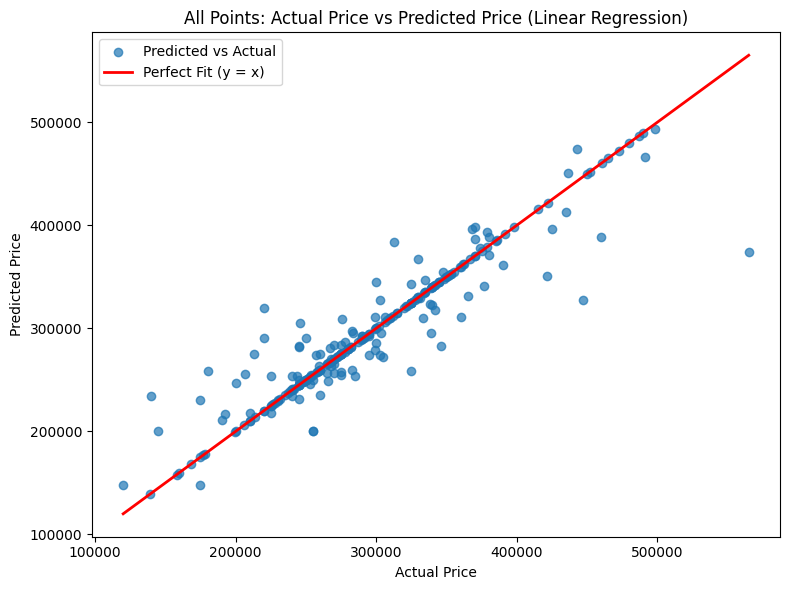

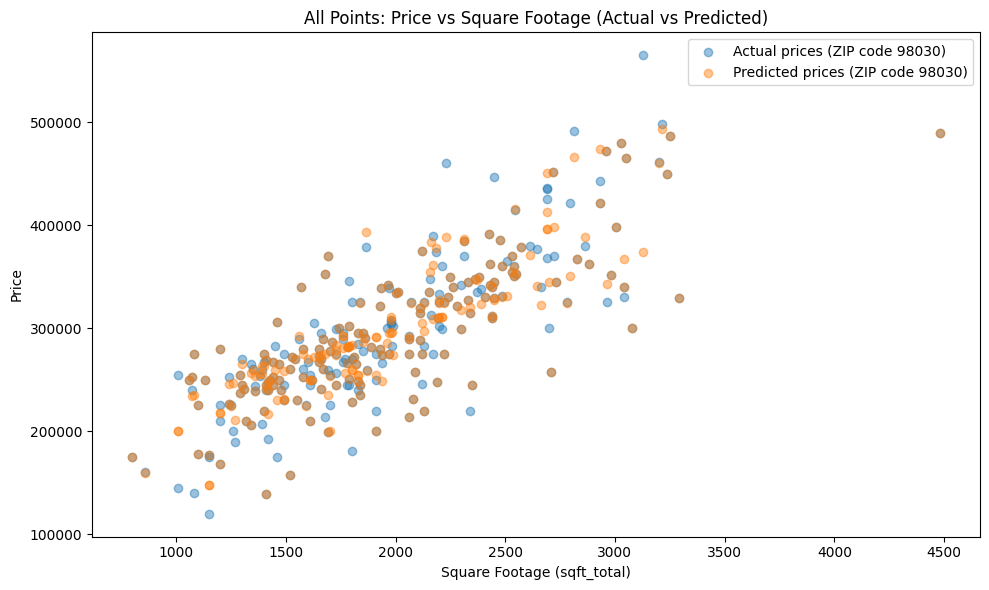

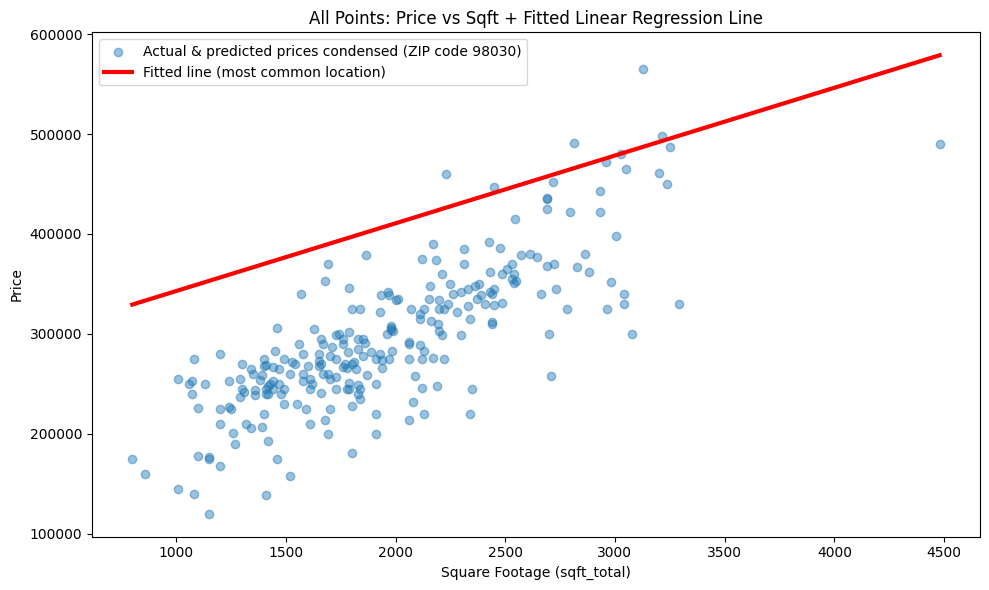

In [1]:
# ------------------------------------------------------------
# IMPORTANT (READ ME BEFORE STARTING)
#
# Ensure you have downloaded "Housing Dataset (Only ZIP code).xlsx" as the excel file obtained from Github.
# USE THE EXCEL FILE AND UPLOAD INTO THE RUNTIME IN COLAB THROUGH THE 'Files' (ON LEFT SIDE BAR), AND DRAG AND DROP THERE.
# ------------------------------------------------------------

# ======================================================
# Dataset Source:
# Kaggle - "Housing Price Prediction" Dataset
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
# ======================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# 1) LOAD THE EXCEL FILE
# ------------------------------------------------------------
file_path = "Housing Dataset (Only ZIP code).xlsx"

df = pd.read_excel(file_path)

# Rename column from "sqft (total" to sqft_total
df = df.rename(columns={"sqft (total)": "sqft_total"})

# Drop rows missing required columns (model cannot train with null values)
df = df.dropna(subset=["price", "sqft_total", "lat", "long"]).copy()

#This section describes the basic features shown from the Housing Dataset (using ZIP code 98030)
print("Rows featured:", len(df)) #Rows involving ZIP code 98030
print("Columns featured:", df.columns.tolist()) #Columns used for the dataset (some will be converted later on)
print("First few rows:") #Features the first 5 rows of the dataset, for reference
print(df.head())

# ------------------------------------------------------------
# 2) BUILD A CATEGORICAL LOCATION FROM (LAT, LONG)
# ------------------------------------------------------------

#This prepares the categorical location for OneHotEncoder later on (ROUND NUMBERS TO THREE DECIMAL PLACES FOR BOTH LATITUDE AND LONGITUDE)
LAT_ROUND = 3
LON_ROUND = 3

df["lat_cell"] = df["lat"].round(LAT_ROUND)
df["lon_cell"] = df["long"].round(LON_ROUND)

# Create a single categorical location label from the coordinate buckets
df["location_cell"] = df["lat_cell"].astype(str) + "," + df["lon_cell"].astype(str)

#Explanation of the location we'll be focusing on (which is ZIP code 98030)
print("\n>Most common location cell using Zip Code 98030:", df["location_cell"].mode()[0])
print("Our common location will take place in King's County, but will be synonmously referencing the ZIP code 98030 as our main location")

# ------------------------------------------------------------
# 3) DEFINE FEATURES (X) AND TARGET (y)
# ------------------------------------------------------------

#Defines & prepares the features for the model(s) represented, using Square Feet Footage, Location Zip Code, and Price overall
X = df[["sqft_total", "location_cell"]]
y = df["price"]


# ------------------------------------------------------------
# 4) TRAIN/TEST SPLIT
# ------------------------------------------------------------

#Samples the code to test out the training model from sklearn (important when we apply the real model with our given dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# 5) PREPROCESSING + LINEAR REGRESSION MODEL PIPELINE
# ------------------------------------------------------------

#Semi-preparation for the upcoming part of creating the Linear Regression model
preprocess = ColumnTransformer(
    transformers=[
        ("loc_ohe", OneHotEncoder(handle_unknown="ignore"), ["location_cell"]),
        ("sqft_pass", "passthrough", ["sqft_total"]),
    ],
    remainder="drop"
)

#Training the model based on x & y coordinates, with the Linear Regression line of "best fit"
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("linreg", LinearRegression())
])

model.fit(X_train, y_train)

# ------------------------------------------------------------
# 6) PREDICT PRICE OF A 2000 SQ FT HOUSE IN THE "SAME LOCATION"
# ------------------------------------------------------------

#This section calculates the prediction of what a 2,000 SQ Foot home would be priced out, given that we assume our coefficient
#(MORE INFORMATION WILL BE SHOWN IN THE MODEL SUMMARY TAB)
common_location = df["location_cell"].mode()[0]

example_house = pd.DataFrame({
    "sqft_total": [2000],
    "location_cell": [common_location]
})

#Calculated price for what 2,000 sqft looks like
predicted_price_2000 = model.predict(example_house)[0]
print(f"\n>Predicted price for 2000 sqft at the most common location: ${predicted_price_2000:,.2f}")

# ------------------------------------------------------------
# 7) PRINT CLEAN MODEL OUTPUT
# ------------------------------------------------------------

#This section features the calculations in the Summary Model, describing the Square Foot Coefficient, Location Adjustments, etc
#(THIS ALSO INCLUDES A LIST OF THE BIGGEST "LOCATION ADJUSTMENTS" BASED ON PRICE, ON THE ONES THAT HAS THE BIGGEST IMPACT OUT OF ALL, CONTRIBUTING TO INTERCEPT)

#This part trains all models for the coefficient, linear regression intercept, and column names (location latitude & longitude)
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["linreg"].coef_
intercept = model.named_steps["linreg"].intercept_

coef_series = pd.Series(coefs, index=feature_names)

# Extract sqft coefficient safely
sqft_feature_name = [n for n in feature_names if "sqft_pass" in n and "sqft_total" in n][0]
beta_sqft = float(coef_series[sqft_feature_name])

# Location adjustment coefficients (one per location_cell category)
location_effects = coef_series.drop(index=sqft_feature_name)

# Sort by absolute magnitude to show biggest effects
location_effects_sorted = location_effects.sort_values(key=np.abs, ascending=False)

#PRINTS THE MODEL SUMMARY HERE
print("\n================ MODEL SUMMARY ================\n")

#In the first part, the intercept is the base price that is mentioned, determining the initial value for the "predicted" price
print(f"Intercept (base price): ${intercept:,.2f}")
print(">The base price is assumed through model training & estimates a common ground point based on the Location Adjustment factor as its starting point")

#In the second part, we are also taking account to identifying the square footage coefficient (that an increase per sqft is an increase of the specified amount)
print("\nSquare footage coefficient:")
print(f"  +${beta_sqft:.2f} per additional square foot")
print(">This means: keeping location fixed, each extra 1 sqft adds about this many dollars to the predicted price.")

#The third part mentions Location Adjustments based on the top 10 location under ZIP code 98030.
#This is a representation on prices adjusted up or down as a factor to the total "predicted" price (but DOESNT AFFECT INTERCEPT IN ANY WAY)
TOP_N = 10
print(f"\nLocation effect summary (top {TOP_N} largest impacts based on OneHotEncoder):")
for i, val in enumerate(location_effects_sorted.head(TOP_N).values, start=1):
    direction = "increase" if val > 0 else "decrease"
    print(f"  Location {i}: {direction} price by ${abs(val):,.2f}")

#Location Adjustment Explanation
print("\n>Location affects price by adding a fixed offset (up/down).")
print(">It does NOT change the sqft slope; it shifts the line vertically depending on the area.")

#The forth part discusses all Linear Regression models that will be demonstrated, with different variabilities & variations to simulate the data closer as insight.
print("\nLinear Regression Models used for Machine Learning:\n")
print("1.) All Points: Actual Price vs Predicted Price - Linear Regression graph based on the comparisons between predicted vs actual price.")
print("2.) All Points: Price vs Square Footage - Displays a model based on actual & predicted prices using Square Footage.")
print("3.) All Points: Price vs Sqft + Fitted Linear Regression Line - Addendum to Model #2, with a linear regression line based on the best fit based on common_location.")

#The fifth part summarizes the overall formula (comprised of the previous parts mentioned in this section)
print("Predicted Price = Intercept + (SquareFootageCoefficient × SquareFootage) + LocationAdjustment")

#In-depth formula for each variable
print("\nWhere:")
print(f"  Intercept = ${intercept:,.2f}")
print(f"  SquareFootageCoefficient = ${beta_sqft:.2f} per sqft")
print("  LocationAdjustment = a learned offset based on the house's (lat/long) location bucket")

# ------------------------------------------------------------
# 8) PLOTS SHOWING THE MODEL WITH ALL POINTS
# ------------------------------------------------------------

#This section plots 3 different models, given with different analysis and characteristics to understand the insight of pricing & predictions further.
#Individually, all 3 models are individually coded under Linear Regression graphs.

# MODEL A) ALL POINTS: Actual vs Predicted
y_pred_all = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_all, alpha=0.7, label="Predicted vs Actual")
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red",
    linewidth=2,
    label="Perfect Fit (y = x)"
)
plt.title("All Points: Actual Price vs Predicted Price (Linear Regression)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.tight_layout()
plt.show()

# MODEL B) ALL POINTS: Price vs Sqft (Actual vs Predicted)
plt.figure(figsize=(10, 6))
plt.scatter(df["sqft_total"], df["price"], alpha=0.45, label="Actual prices (ZIP code 98030)")
plt.scatter(df["sqft_total"], y_pred_all, alpha=0.45, label="Predicted prices (ZIP code 98030)")
plt.title("All Points: Price vs Square Footage (Actual vs Predicted)")
plt.xlabel("Square Footage (sqft_total)")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

# MODEL C) ALL POINTS: Price vs Sqft + FITTED LINE (Most Common Location)
internal_loc_feature_name = "loc_ohe__location_cell_" + common_location
beta_loc = float(coef_series.get(internal_loc_feature_name, 0.0))

sqft_min, sqft_max = df["sqft_total"].min(), df["sqft_total"].max()
sqft_line = np.linspace(sqft_min, sqft_max, 200)

price_line = intercept + beta_loc + beta_sqft * sqft_line

plt.figure(figsize=(10, 6))
plt.scatter(df["sqft_total"], df["price"], alpha=0.45, label="Actual & predicted prices condensed (ZIP code 98030)")
plt.plot(sqft_line, price_line, color="red", linewidth=3, label="Fitted line (most common location)")
plt.title("All Points: Price vs Sqft + Fitted Linear Regression Line")
plt.xlabel("Square Footage (sqft_total)")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()
